In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [6]:
df.shape

(4340, 8)

In [7]:
df['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

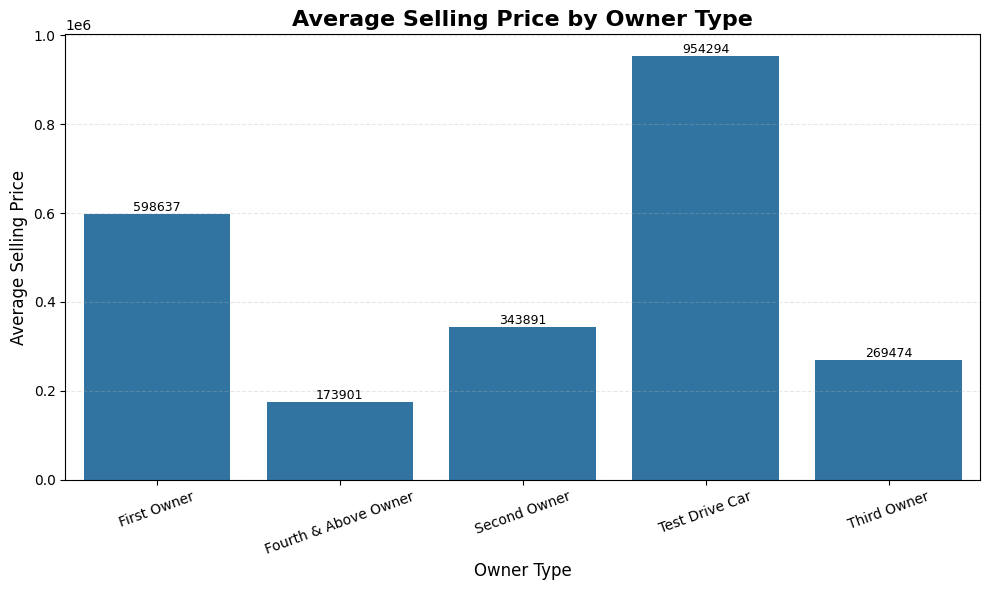

In [8]:
owner_price = (
    df.groupby('owner')['selling_price']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=owner_price,
    x='owner',
    y='selling_price'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=9
    )

plt.title(
    'Average Selling Price by Owner Type',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Owner Type', fontsize=12)
plt.ylabel('Average Selling Price', fontsize=12)

plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

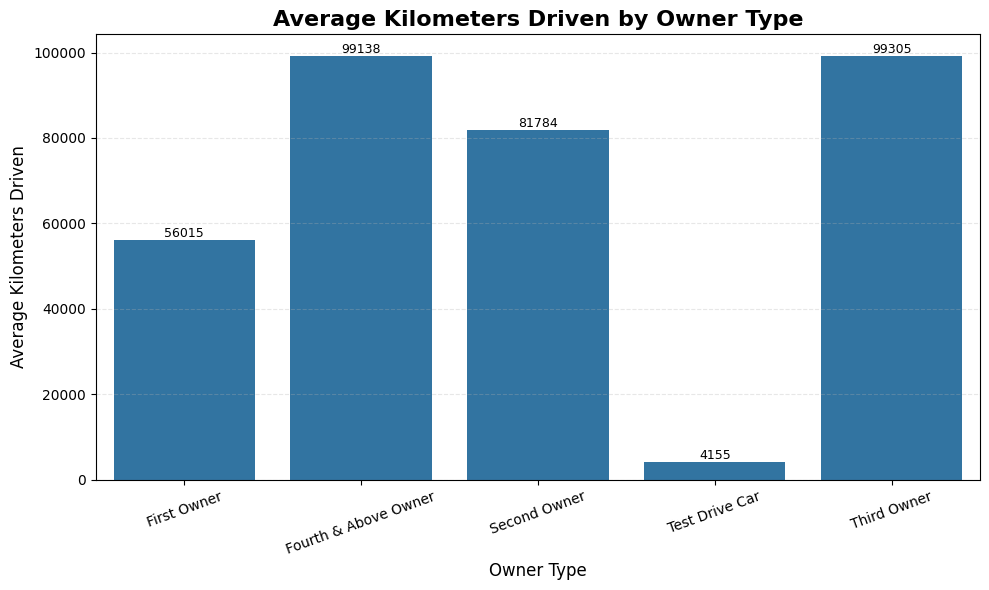

In [9]:
owner_km = (
    df.groupby('owner')['km_driven']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=owner_km,
    x='owner',
    y='km_driven'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=9
    )

plt.title(
    'Average Kilometers Driven by Owner Type',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Owner Type', fontsize=12)
plt.ylabel('Average Kilometers Driven', fontsize=12)

plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

## 💡 Insight 1: Owner Type vs Selling Price

The analysis shows that **First Owner** vehicles achieved significantly higher average selling prices compared to cars with multiple previous owners. In contrast, **Third Owner** and **Fourth & Above Owner** vehicles recorded substantially lower resale values, indicating that ownership history is an important factor influencing a car's market price.

Supporting analysis revealed that **First Owner** cars had the **lowest average kilometers driven (56,015 km)** among regular ownership categories, whereas **Third Owner** and **Fourth & Above Owner** vehicles had nearly **100,000 km** on average. This suggests that first-owner vehicles are generally less used and are perceived to be in better condition, making them more attractive to buyers and allowing dealers to command higher resale prices. The **Test Drive** category also recorded the highest average selling price, which is expected because these vehicles have extremely low mileage and are nearly new.

In [10]:
df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

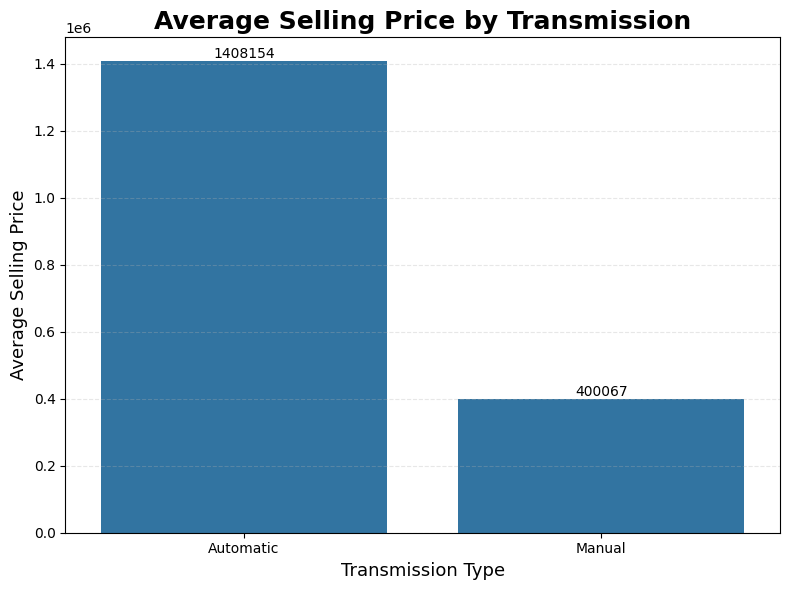

In [11]:
transmission_price = (
    df.groupby('transmission')['selling_price']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=transmission_price,
    x='transmission',
    y='selling_price'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=10
    )

plt.title(
    'Average Selling Price by Transmission',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Transmission Type', fontsize=13)
plt.ylabel('Average Selling Price', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

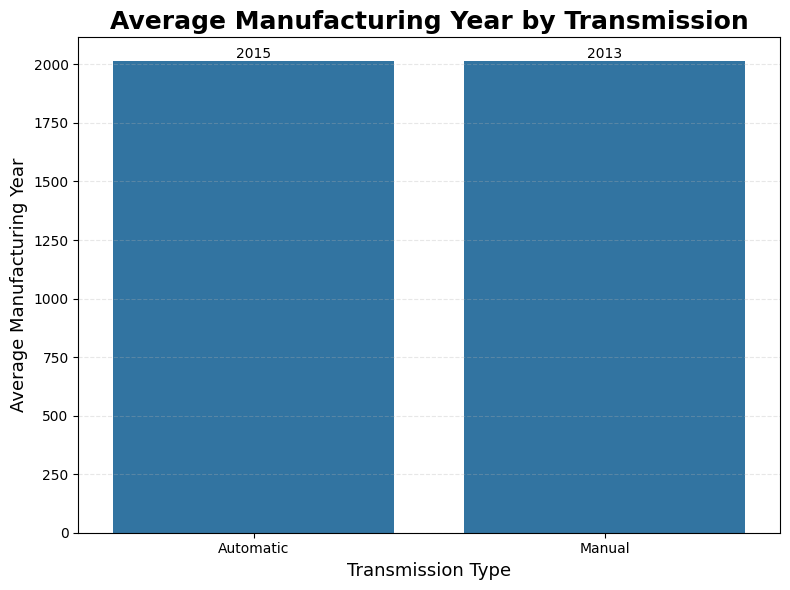

In [12]:
transmission_year = (
    df.groupby('transmission')['year']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=transmission_year,
    x='transmission',
    y='year'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=10
    )

plt.title(
    'Average Manufacturing Year by Transmission',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Transmission Type', fontsize=13)
plt.ylabel('Average Manufacturing Year', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

## 💡 Insight 2: Transmission Type vs Selling Price

The analysis shows that **Automatic transmission** vehicles achieved a significantly higher average selling price (**₹1,408,154**) compared to **Manual transmission** vehicles (**₹400,067**). This indicates that transmission type plays an important role in determining a vehicle's resale value, with buyers generally willing to pay a premium for automatic cars.

Supporting analysis revealed that **Automatic cars had a newer average manufacturing year (2015)** compared to **Manual cars (2013)**. This suggests that automatic vehicles are generally more recent models equipped with modern technology, improved driving comfort, and updated features, making them more desirable in the used car market. As a result, dealers can justify higher resale prices for automatic transmission vehicles.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [14]:
df['KM_Group'] = pd.cut(
    df['km_driven'],
    bins=[0, 30000, 60000, 100000, 500000],
    labels=[
        'Low (<30K)',
        'Moderate (30K-60K)',
        'High (60K-100K)',
        'Very High (>100K)'
    ]
)

/tmp/ipykernel_5039/1468685418.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('KM_Group')['selling_price']


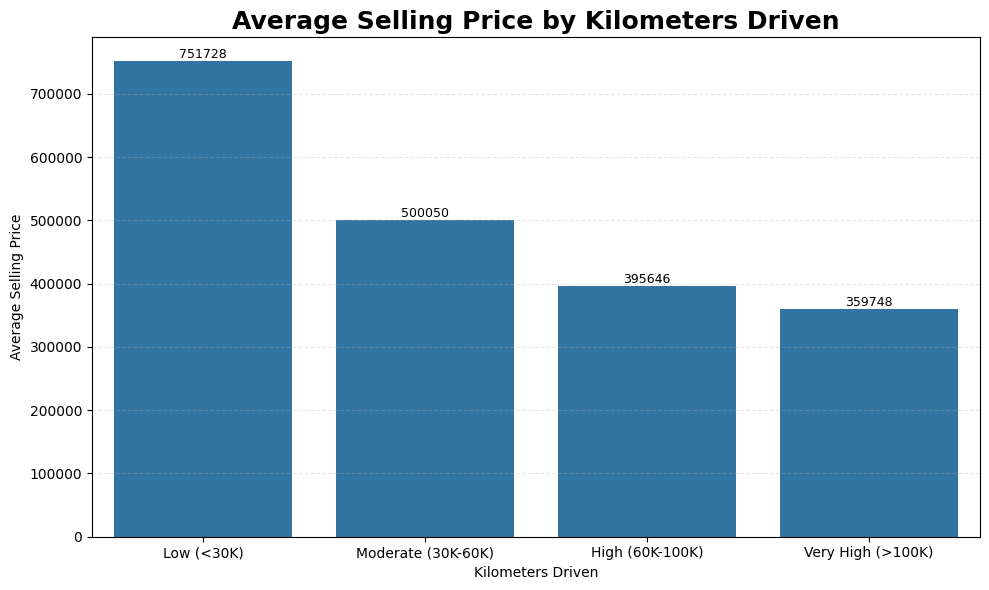

In [15]:
km_price = (
    df.groupby('KM_Group')['selling_price']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=km_price,
    x='KM_Group',
    y='selling_price'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=9
    )

plt.title(
    'Average Selling Price by Kilometers Driven',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Kilometers Driven')
plt.ylabel('Average Selling Price')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

/tmp/ipykernel_5039/2743839648.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('KM_Group')['year']


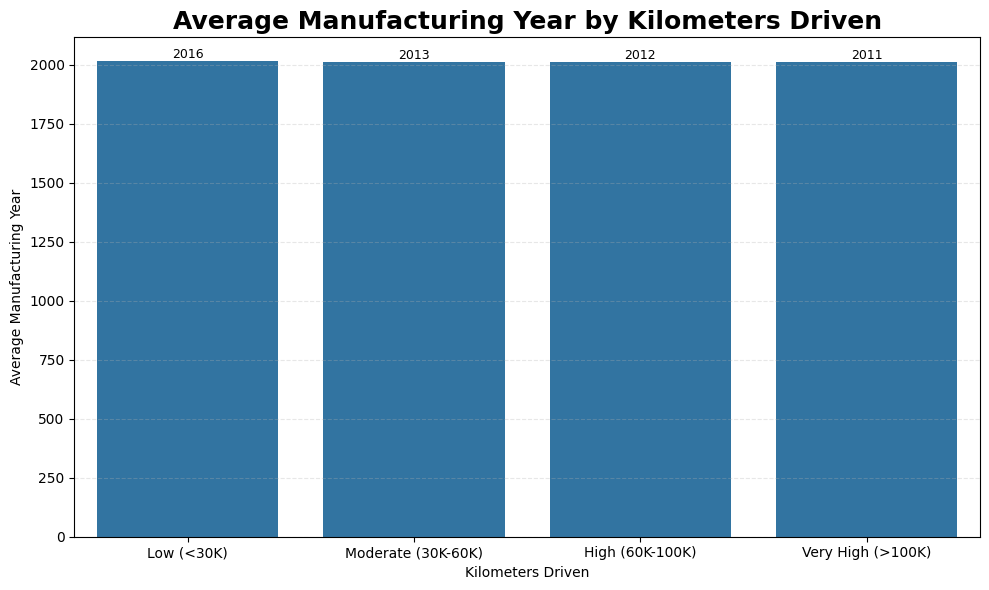

In [16]:
km_year = (
    df.groupby('KM_Group')['year']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=km_year,
    x='KM_Group',
    y='year'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=9
    )

plt.title(
    'Average Manufacturing Year by Kilometers Driven',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Kilometers Driven')
plt.ylabel('Average Manufacturing Year')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

## 💡 Insight 3: Kilometers Driven vs Selling Price

The analysis shows that vehicles with **lower mileage** achieved the highest average selling prices. Cars driven **less than 30,000 km** recorded an average selling price of **₹751,728**, while vehicles with **more than 100,000 km** were valued significantly lower at **₹359,748**. This demonstrates that mileage is one of the most important factors influencing a vehicle's resale value, as buyers generally associate lower mileage with better condition and a longer remaining lifespan.

Supporting analysis revealed that **low-mileage vehicles were also the newest**, with an average manufacturing year of **2016**, whereas vehicles driven **more than 100,000 km** had an average manufacturing year of **2011**. This indicates that newer cars naturally accumulate fewer kilometers over time, experience less wear and tear, and therefore retain a higher market value. Dealers can confidently price low-mileage, newer vehicles at a premium because they are perceived as more reliable and require fewer immediate repairs.

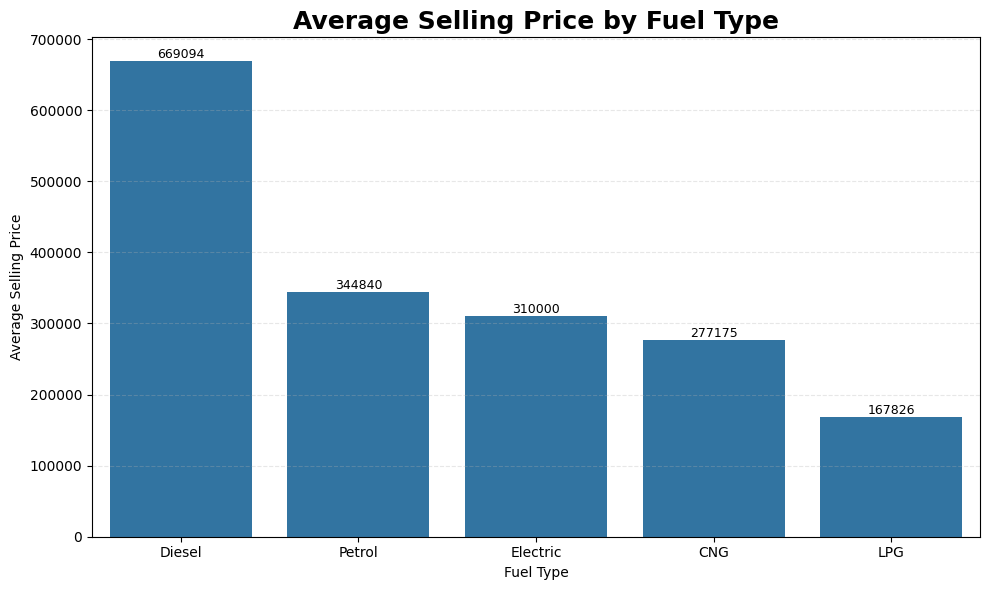

In [17]:
fuel_price = (
    df.groupby('fuel')['selling_price']
      .mean()
      .reset_index()
      .sort_values(by='selling_price', ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=fuel_price,
    x='fuel',
    y='selling_price'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=9
    )

plt.title(
    'Average Selling Price by Fuel Type',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

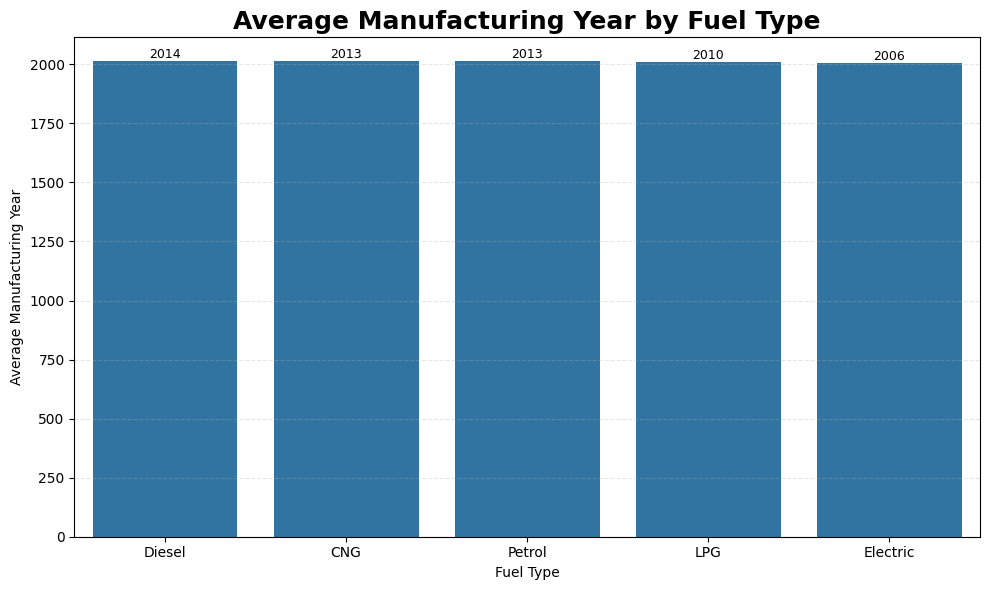

In [18]:
fuel_year = (
    df.groupby('fuel')['year']
      .mean()
      .reset_index()
      .sort_values(by='year', ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=fuel_year,
    x='fuel',
    y='year'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=9
    )

plt.title(
    'Average Manufacturing Year by Fuel Type',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Fuel Type')
plt.ylabel('Average Manufacturing Year')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

## 💡 Insight 4: Fuel Type vs Selling Price

The analysis shows that **Diesel** vehicles achieved the highest average selling price (**₹669,094**), followed by **Petrol** vehicles (**₹344,840**). In contrast, **LPG** vehicles recorded the lowest average resale value (**₹167,826**). This indicates that fuel type significantly influences a vehicle's market value, with buyers generally willing to pay more for diesel-powered cars.

Supporting analysis revealed that **Diesel** vehicles had the newest average manufacturing year (**2014**) among all fuel types, while **Electric** vehicles in this dataset had the oldest average manufacturing year (**2006**). This suggests that the higher resale value of diesel vehicles is associated with their relatively newer models, better market demand, and longer perceived usability. Conversely, older fuel-type vehicles tend to command lower resale prices due to greater depreciation and reduced buyer demand.

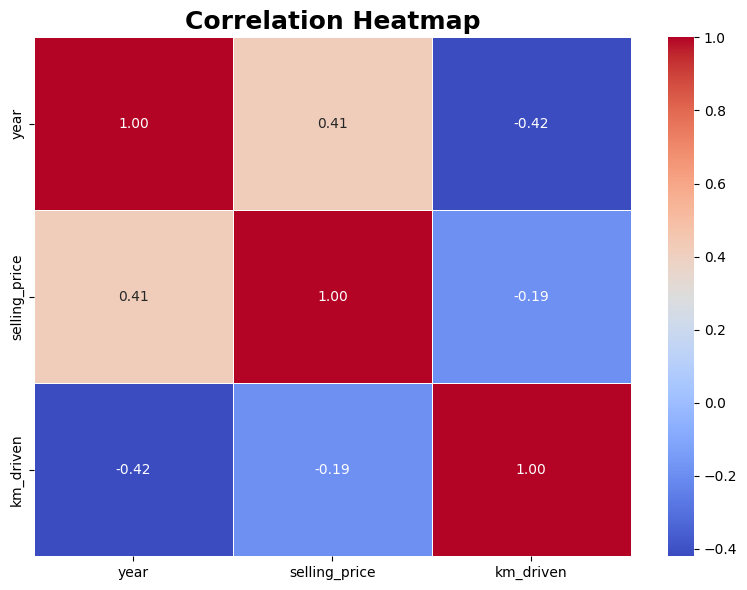

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[
    [
        'year',
        'selling_price',
        'km_driven'
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

## 📊 Correlation Heatmap

The correlation heatmap was used to examine the relationships among the key numerical variables in the dataset, including **Manufacturing Year**, **Selling Price**, and **Kilometers Driven**.

The analysis indicates that **Selling Price** has a **positive relationship with Manufacturing Year**, suggesting that newer vehicles generally command higher resale values. In contrast, **Kilometers Driven** exhibits a **negative relationship with Selling Price**, indicating that vehicles with higher mileage tend to have lower market values due to increased wear and depreciation.

Overall, the heatmap confirms that **vehicle age and mileage are the two primary numerical factors influencing resale prices**, reinforcing the business insights derived from the previous analyses.

# 📝 Conclusion

This exploratory analysis examined the key factors influencing used car resale prices using a dataset of 4,340 vehicles. The study focused on understanding how ownership history, transmission type, vehicle usage, fuel type, and manufacturing year contribute to a vehicle's market value.

The analysis revealed that **First Owner** vehicles generally achieved higher selling prices because they had significantly lower average mileage than vehicles with multiple previous owners. **Automatic transmission** vehicles also commanded substantially higher resale values and were, on average, newer than manual vehicles, indicating that modern features and vehicle age positively influence market prices.

Mileage emerged as one of the strongest pricing factors, with **low-mileage vehicles retaining considerably higher resale values** than heavily driven cars. Supporting analysis further demonstrated that newer vehicles naturally accumulated fewer kilometers, helping them maintain better condition and stronger resale prices. Additionally, **Diesel vehicles** recorded the highest average selling prices within this dataset, partly because they were among the newest vehicles available.

The correlation heatmap further confirmed that **Manufacturing Year** and **Kilometers Driven** are the primary numerical factors affecting resale prices. Newer vehicles generally retain higher value, while increased mileage contributes to vehicle depreciation and lower market prices.

Overall, this analysis demonstrates that **used car pricing depends on a combination of ownership history, vehicle age, mileage, transmission type, and fuel type rather than a single factor**. By evaluating these characteristics together, used car dealers can make more informed purchasing decisions, estimate fair resale prices, and maximize profitability while offering competitive prices to customers.